# Alpha phase estimation using PHASTIMATE

In [12]:
import sys
import numpy as np
import scipy.signal as signal

sys.path.append("../../..")

from EEGPhasePy.estimators import PHASTIMATE

Generate the simulated training and testing EEG data

In [13]:
fs = 2000
time_data = np.arange(0, 200, 1/fs)

signal_clean = np.sin(2 * np.pi * 10 * time_data)
signal_noisy = signal_clean + np.random.normal(0, 2, len(time_data))

Define the real-time and ground-truth alpha bandpass filters. 

The real-time filter should be lower order since it will be applied to a window with fewer samples than the ground truth filter. The ground truth filter is what will be used to extract the phase for phase stats (i.e. accuracy, mean and std of phase) as well as to generate the polar histogram and trigger waveform plots

In [14]:
rt_filter = signal.firwin(120, [8, 12], fs=fs, pass_zero=False)
gt_filter = signal.firwin(300, [8, 12], fs=fs, pass_zero=False)

Next, we will instantiate PHASTIMATE. 

Unlike ETP, PHASTIMATE doesn't necessarily require training data. With the right parameters
it can work out of the box. However, you may benefit from optimizing the `window_edge` and `ar_order` parameters in the class, especially 
when there is a variability in SNR across participants.

In [15]:
phastimate = PHASTIMATE(rt_filter, gt_filter, fs, window_edge=35, ar_order=15)

Now, we will run a pseudo-real-time simulation using the testing signal. Here, we use the `predict` method of the `phastimate`
object. `predict` works by returning a boolean value about whether the current phase is your target phase. A tolerance value may also be 
passed in. By default tolerance is 5 degrees. Tolerance indicates how close the current phase must be to the target phase for `predict`
to return `True`.

In [16]:
window_i = 2*fs
window_len = int(0.5*fs)
window_step = int(0.06*fs) # using a step of 60 ms

triggers = []

while window_i + window_len < len(signal_noisy):
    window = signal_noisy[window_i:window_i + window_len]

    if phastimate.predict(window, 0, 15):
        triggers.append(window_i + window_len)
        
    window_i += window_step

Mean phase: 5.74749089554723
Std phase: 2.2117837843101813
Accuracy: 99.97194159867503


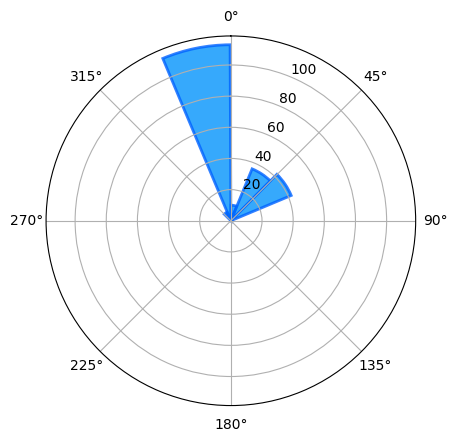

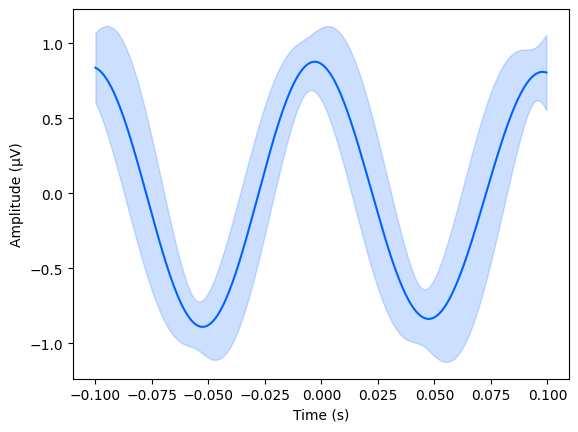

In [17]:
polar_hist_fig = phastimate.polar_histogram_from_triggers(signal_noisy, triggers)
waveform_fig = phastimate.plot_mean_std_waveform_from_triggers(signal_noisy, triggers, tmin=0.1, tmax=0.1)

phase_standard_deviation = phastimate.std_phase_from_triggers(signal_noisy, triggers, degree=True)
phase_mean = phastimate.mean_phase_from_triggers(signal_noisy, triggers, degree=True)
accuracy = phastimate.phase_accuracy_from_triggers(signal_noisy, triggers, 0)

print("Mean phase: " + str(phase_mean))
print("Std phase: " + str(phase_standard_deviation))
print("Accuracy: " + str(100*accuracy))

As with ETP, PHASTIMATE can also quite easily detect different phases simply by changing the `target_phase` argument (which uses degrees)

Mean phase: 3.144091515041629
Std phase: 2.207799265331086
Accuracy: 99.45485930715404


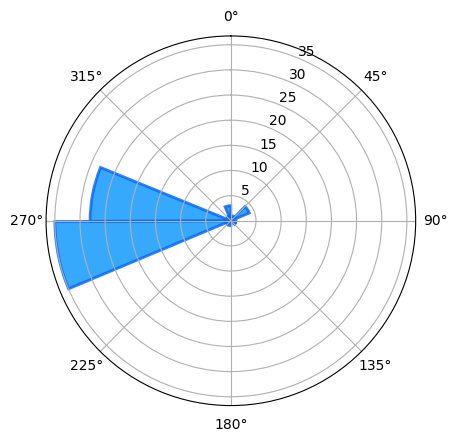

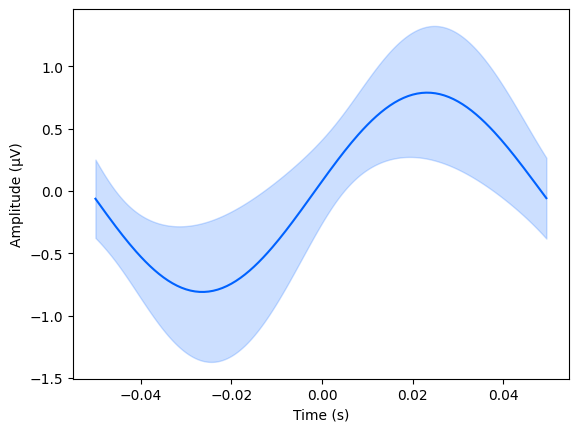

In [18]:
window_i = 2*fs
window_len = int(0.5*fs)
window_step = int(0.06*fs) # using a step of 60 ms

triggers = []

while window_i + window_len < len(signal_noisy):
    window = signal_noisy[window_i:window_i + window_len]
    
    if phastimate.predict(window, 270, 2):
        triggers.append(window_i + window_len)
    window_i += window_step

polar_hist_fig = phastimate.polar_histogram_from_triggers(signal_noisy, triggers)
waveform_fig = phastimate.plot_mean_std_waveform_from_triggers(signal_noisy, triggers, tmin=0.05, tmax=0.05)

phase_standard_deviation = phastimate.std_phase_from_triggers(signal_noisy, triggers, degree=True)
phase_mean = phastimate.mean_phase_from_triggers(signal_noisy, triggers, degree=True)
accuracy = phastimate.phase_accuracy_from_triggers(signal_noisy, triggers, 270)

print("Mean phase: " + str(phase_mean))
print("Std phase: " + str(phase_standard_deviation))
print("Accuracy: " + str(100*accuracy))

Similarly, to target troughs, instead of peaks, we just change the `target_phase` to $`90\deg`$

Mean phase: 4.765206092762474
Std phase: 2.785026228639683
Accuracy: 99.86836279565034


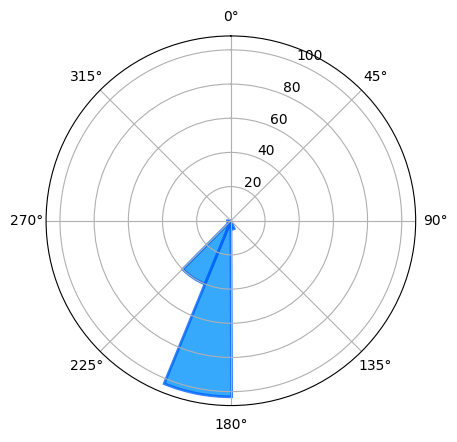

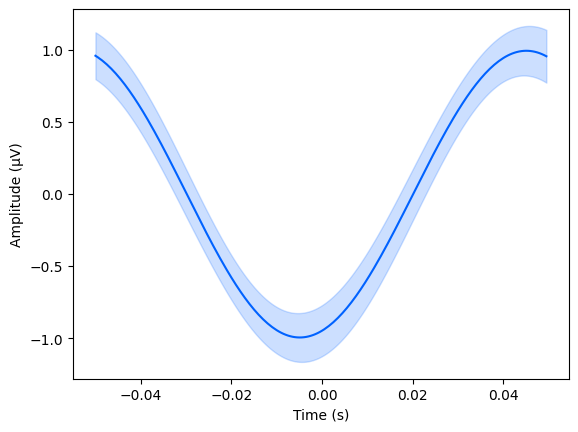

In [19]:
window_i = 2*fs
window_len = int(0.5*fs)
window_step = int(0.06*fs) # using a step of 60 ms

triggers = []

while window_i + window_len < len(signal_noisy):
    window = signal_noisy[window_i:window_i + window_len]
    
    if phastimate.predict(window, 180, 5):
        triggers.append(window_i + window_len)
    window_i += window_step

polar_hist_fig = phastimate.polar_histogram_from_triggers(signal_noisy, triggers)
waveform_fig = phastimate.plot_mean_std_waveform_from_triggers(signal_noisy, triggers, tmin=0.05, tmax=0.05)

phase_standard_deviation = phastimate.std_phase_from_triggers(signal_noisy, triggers, degree=True)
phase_mean = phastimate.mean_phase_from_triggers(signal_noisy, triggers, degree=True)
accuracy = phastimate.phase_accuracy_from_triggers(signal_noisy, triggers, 180)

print("Mean phase: " + str(phase_mean))
print("Std phase: " + str(phase_standard_deviation))
print("Accuracy: " + str(100*accuracy))